# SMAI Assignment 2 - Question 2
## Vision in the Real World - Indian Currency Classification

---

Onedrive Link to the Datasets Created for Training - [Datasets](https://iiithydresearch-my.sharepoint.com/:f:/g/personal/harsh_kapoor_research_iiit_ac_in/IgC7kokn8t7VRqIdtWa2Tnz5AZF8qeSN02W5iSaAelYTCos?e=p7YVqO)

## Part A: Theoretical Foundations

#### 2A.1 Spatial Dimension Calculations

$$
O = \left\lfloor \frac{I - K + 2P}{S} \right\rfloor + 1
$$

where:
- $I$ = input size
- $K$ = kernel size
- $P$ = padding
- $S$ = stride

##### (a) Output volume after Conv2D(32 filters, kernel $3\times3$, stride $2$, padding $1$) on input $3\times128\times128$

Spatial size:

$$
O = \left\lfloor \frac{128 - 3 + 2(1)}{2} \right\rfloor + 1
= \left\lfloor \frac{127}{2} \right\rfloor + 1
= 63 + 1 = 64
$$

So the output volume is:

$$
\boxed{32 \times 64 \times 64}
$$

##### (b) Pass this output through Conv2D(64 filters, kernel $3\times3$, stride $1$, padding $1$)

Input to this layer is $32\times64\times64$.

Spatial size:

$$
O = \left\lfloor \frac{64 - 3 + 2(1)}{1} \right\rfloor + 1
= \left\lfloor 63 \right\rfloor + 1
= 64
$$

So the resulting output volume is:

$$
\boxed{64 \times 64 \times 64}
$$

#### 2A.2 Receptive Field

##### (a) Define receptive field of a neuron in a convolutional layer. Why is it important for a network to have a receptive field that covers a large portion of the input image?

The **receptive field** of a neuron is the region of the input image that can influence that neuron's activation.

Why it matters:
- Small receptive fields capture local patterns (edges, textures).
- Larger receptive fields capture global structure (object shape and context).
- For tasks like currency classification, larger effective receptive fields help the model use full-note layout cues, not just tiny patches.

##### (b) Calculate the receptive field at the output of two stacked $3\times3$ convolutions (both stride $1$, no pooling). Compare this to a single $5\times5$ convolution. Which uses fewer parameters?

For stride $1$, receptive field grows as:

$$
R_{\text{new}} = R_{\text{old}} + (K - 1)
$$

Starting with $R_0 = 1$:

$$
R_1 = 1 + (3 - 1) = 3
$$

$$
R_2 = 3 + (3 - 1) = 5
$$

So two stacked $3\times3$ convolutions give an effective receptive field of:

$$
\boxed{5 \times 5}
$$

This matches the receptive field of one $5\times5$ convolution.

Parameter comparison (assuming same input/output channel width $C$ and ignoring bias):

$$
\text{Two }3\times3: \; 2 \cdot (3\cdot3\cdot C^2) = 18C^2
$$

$$
\text{One }5\times5: \; 5\cdot5\cdot C^2 = 25C^2
$$

Hence, two stacked $3\times3$ layers use fewer parameters:

$$
\boxed{18C^2 < 25C^2}
$$

#### 2A.3 Parameter Efficiency

##### (a) Calculate the exact number of learnable parameters (weights + biases) for a standard Conv2D layer mapping 32 input channels to 64 output channels with a $3\times3$ kernel.

For a standard Conv2D:

$$
\text{Weights} = K_h \cdot K_w \cdot C_{in} \cdot C_{out}
$$

$$
\text{Biases} = C_{out}
$$

Substitute $K_h=K_w=3$, $C_{in}=32$, $C_{out}=64$:

$$
\text{Weights} = 3 \cdot 3 \cdot 32 \cdot 64 = 18432
$$

$$
\text{Biases} = 64
$$

$$
\boxed{\text{Total} = 18432 + 64 = 18496}
$$

##### (b) Calculate parameters for the same mapping using a depthwise separable convolution (a $3\times3$ depthwise conv followed by a $1\times1$ pointwise conv). Include biases.

Depthwise stage ($3\times3$, one filter per input channel):

$$
\text{Weights}_{dw} = 3 \cdot 3 \cdot 32 = 288,
\quad
\text{Biases}_{dw} = 32
$$

$$
\text{Total}_{dw} = 288 + 32 = 320
$$

Pointwise stage ($1\times1$, maps $32 \to 64$):

$$
\text{Weights}_{pw} = 1 \cdot 1 \cdot 32 \cdot 64 = 2048,
\quad
\text{Biases}_{pw} = 64
$$

$$
\text{Total}_{pw} = 2048 + 64 = 2112
$$

Overall depthwise separable total:

$$
\boxed{\text{Total}_{sep} = 320 + 2112 = 2432}
$$

##### (c) Compute the compression ratio. Why do MobileNet-style architectures rely heavily on this factorization?

Compression ratio (standard vs separable):

$$
\text{Compression Ratio} = \frac{18496}{2432} \approx 7.61
$$

So depthwise separable convolution uses about $7.61\times$ fewer parameters (or about $86.85\%$ reduction).

Why MobileNet uses this:
- Much lower parameter count and memory footprint.
- Fewer multiply-add operations, so faster inference on mobile/edge hardware.
- Preserves much of the representational power by separating spatial filtering (depthwise) and channel mixing (pointwise).

#### 2A.4 BatchNorm vs. LayerNorm - Choosing the Right Normalization

##### (a) BatchNorm axis. In a CNN with feature maps of shape $(B, C, H, W)$, BatchNorm computes mean and variance over which axes?

For `BatchNorm2d`, normalization is done **per channel** $c$ using statistics computed across:

$$
(B, H, W) \quad \text{for each fixed } c
$$

So:
- Mean/variance are computed over batch and spatial dimensions.
- Each channel has its own learned affine parameters $(\gamma_c, \beta_c)$.

Equivalent expression:

$$
\mu_c = \frac{1}{BHW} \sum_{b,h,w} x_{b,c,h,w},
\qquad
\sigma_c^2 = \frac{1}{BHW} \sum_{b,h,w} (x_{b,c,h,w}-\mu_c)^2
$$

##### (b) Small-batch failure mode. Suppose batch size is 2. Explain why BatchNorm statistics become unreliable. Name one alternative (other than LayerNorm) robust to small batch sizes.

With batch size $B=2$, BatchNorm estimates of mean/variance are noisy because they are computed from very few samples.

Effects:
- High variance in batch statistics from step to step.
- Unstable training and sensitivity to sample composition.
- Mismatch between training-time batch stats and inference-time running stats.

A robust alternative is **GroupNorm** (also acceptable: InstanceNorm), because it does not depend on batch-level statistics.

##### (c) Why not BatchNorm in Transformers?

In NLP Transformers, sequences in a batch often have different lengths and include padding.

Why BatchNorm is problematic:
- BN mixes statistics across the batch dimension, coupling unrelated tokens/sentences.
- Variable lengths and padding can distort batch statistics.
- Behavior depends strongly on batch composition and size.

Why LayerNorm is preferred:
- LayerNorm normalizes each token independently across its feature dimension.
- It is independent of batch size and sequence-length distribution.
- This makes training/inference behavior more stable and consistent, so it is the standard choice in Transformers.

## Part B: Practical Implementation

The Datasets need to be downloaded from the Onedrive Link, given at the start of the report and then placed in the following manner -
```text
.
├── Dataset/
│   ├── Notes_10/
│   │   ├── img1.jpg
│   │   ├── img2.jpg
│   │   └── ...
│   ├── Notes_20/
│   ├── Notes_50/
│   ├── Notes_100/
│   ├── Notes_200/
│   ├── Notes_500/
│   └── Notes_2000/
│
├── Test_Notes_Augmented/
│   ├── 10_1_orig.jpeg
│   ├── 10_1_rot180.jpeg
│   ├── 50_4_orig.jpeg
│   ├── 500_3_rot180.jpeg
│   └── ...
│
└── Models/   (auto-created; stores trained .pth files)
```

- `Dataset/` is read using `ImageFolder`, so each class must be a separate subfolder (`Notes_*`).
- Train/test split is created in code (80/20), so no separate train/test folders are required inside `Dataset/`.

Dataset Directory has the images used for training and validations (mentioned as test in train phase), using a random 80:20 split. The Test_Notes_Augmented Directory has the test images used for inference. First number of the images in the testing directory tells the true class to the eval script during inference, whereas the sub direectory in the Dataset folder tells the true class in the training.

##### Imports and Initialize Paths.

In [ ]:
# !pip install grad-cam seaborn scikit-learn
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = './Dataset'
IMG_SIZE = 128
BATCH_SIZE = 32

# Ensure the Models directory exists
os.makedirs('Models', exist_ok=True)

print(f"[*] Using device: {DEVICE}")

[*] Using device: cpu


##### Model Architecture Definitions

 following are ther model architecture definitions used in this notebook:

- **BaselineCurrencyCNN**: Standard CNN with Conv-BN-ReLU-MaxPool blocks, followed by Global Average Pooling and a linear classifier (2B.1).
- **MobileCurrencyCNN**: Lightweight CNN using **depthwise separable convolutions** in deeper blocks for parameter efficiency (2B.2 and 2B.3).
- **SuperCurrencyCNN**: Higher-capacity model with stronger regularization (Dropout/Dropout2d), deeper feature extraction, and improved robustness (Not of any specific question, did it for fun and pushing model to better accuracies).
- **Utility function**: `count_parameters(model)` is included to compare trainable parameter counts across models.

In [2]:
# ================================
# 1. MODEL ARCHITECTURES
# ================================

# --- Baseline Architecture ---
class BaselineCurrencyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# --- Mobile Architecture ---
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, 3, padding=1, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))

class MobileCurrencyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def standard_conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )
        def separable_conv_block(in_c, out_c):
            return nn.Sequential(
                DepthwiseSeparableConv(in_c, out_c),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )
        self.block1 = standard_conv_block(3, 32)
        self.block2 = standard_conv_block(32, 64)
        self.block3 = separable_conv_block(64, 128)
        self.block4 = separable_conv_block(128, 256)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# --- Super Model Architecture ---
class SuperCurrencyCNN(nn.Module):
    def __init__(self, num_classes):
        super(SuperCurrencyCNN, self).__init__()
        def conv_block(in_c, out_c, drop_rate=0.0):
            layers = [
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.1, inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2)
            ]
            if drop_rate > 0:
                layers.append(nn.Dropout2d(drop_rate))
            return nn.Sequential(*layers)
            
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128, drop_rate=0.1),
            conv_block(128, 256, drop_rate=0.2),
            conv_block(256, 512, drop_rate=0.3)
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# --- Utility: Parameter Counting ---
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#### 2B.1 Baseline CNN

following is the train script for the Baseline CNN, 4 convoluitonal blocks with each block having (Conv2D -> BatchNorm -> ReLU -> MaxPool(2)). Ending with global average pooling and a single linear layer. Trained for 15 epochs.

In [3]:
# ================================
# 2. TRAIN BASELINE MODEL
# ================================
MODEL_SAVE_PATH_BASE = 'Models/q2_baseline_cnn.pth'
EPOCHS_BASE = 15

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("[*] Loading dataset for Baseline...")
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=base_transform)
class_names = full_dataset.classes

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

baseline_model = BaselineCurrencyCNN(num_classes=len(class_names)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

print("[*] Starting training phase for Baseline CNN...")
for epoch in range(EPOCHS_BASE):
    baseline_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = baseline_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
            
    train_acc = 100 * correct_train / total_train
    avg_train_loss = running_loss / len(train_loader)
    
    baseline_model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = baseline_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    test_acc = 100 * correct_test / total_test
    print(f"Epoch [{epoch+1}/{EPOCHS_BASE}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

torch.save({'model_state_dict': baseline_model.state_dict(), 'class_names': class_names}, MODEL_SAVE_PATH_BASE)
print(f"[*] Baseline Model saved to {MODEL_SAVE_PATH_BASE}")

[*] Loading dataset for Baseline...
[*] Starting training phase for Baseline CNN...
Epoch [1/15] | Train Loss: 1.3802 | Train Acc: 45.83% | Test Acc: 42.98%
Epoch [2/15] | Train Loss: 1.0886 | Train Acc: 59.78% | Test Acc: 61.84%
Epoch [3/15] | Train Loss: 0.8669 | Train Acc: 69.26% | Test Acc: 71.84%
Epoch [4/15] | Train Loss: 0.6976 | Train Acc: 75.87% | Test Acc: 71.00%
Epoch [5/15] | Train Loss: 0.6008 | Train Acc: 78.93% | Test Acc: 76.94%
Epoch [6/15] | Train Loss: 0.5083 | Train Acc: 82.37% | Test Acc: 75.33%
Epoch [7/15] | Train Loss: 0.4588 | Train Acc: 84.57% | Test Acc: 78.55%
Epoch [8/15] | Train Loss: 0.4024 | Train Acc: 86.34% | Test Acc: 84.63%
Epoch [9/15] | Train Loss: 0.3471 | Train Acc: 88.40% | Test Acc: 86.65%
Epoch [10/15] | Train Loss: 0.3222 | Train Acc: 89.27% | Test Acc: 79.18%
Epoch [11/15] | Train Loss: 0.2863 | Train Acc: 90.37% | Test Acc: 86.51%
Epoch [12/15] | Train Loss: 0.2524 | Train Acc: 91.77% | Test Acc: 87.84%
Epoch [13/15] | Train Loss: 0.2386 | 

##### Baseline CNN Training Summary (Q2B.1)

    [*] Loading dataset for Baseline...
    [*] Starting training phase for Baseline CNN...
    Epoch [1/15] | Train Loss: 1.3802 | Train Acc: 45.83% | Test Acc: 42.98%
    Epoch [2/15] | Train Loss: 1.0886 | Train Acc: 59.78% | Test Acc: 61.84%
    Epoch [3/15] | Train Loss: 0.8669 | Train Acc: 69.26% | Test Acc: 71.84%
    Epoch [4/15] | Train Loss: 0.6976 | Train Acc: 75.87% | Test Acc: 71.00%
    Epoch [5/15] | Train Loss: 0.6008 | Train Acc: 78.93% | Test Acc: 76.94%
    Epoch [6/15] | Train Loss: 0.5083 | Train Acc: 82.37% | Test Acc: 75.33%
    Epoch [7/15] | Train Loss: 0.4588 | Train Acc: 84.57% | Test Acc: 78.55%
    Epoch [8/15] | Train Loss: 0.4024 | Train Acc: 86.34% | Test Acc: 84.63%
    Epoch [9/15] | Train Loss: 0.3471 | Train Acc: 88.40% | Test Acc: 86.65%
    Epoch [10/15] | Train Loss: 0.3222 | Train Acc: 89.27% | Test Acc: 79.18%
    Epoch [11/15] | Train Loss: 0.2863 | Train Acc: 90.37% | Test Acc: 86.51%
    Epoch [12/15] | Train Loss: 0.2524 | Train Acc: 91.77% | Test Acc: 87.84%
    Epoch [13/15] | Train Loss: 0.2386 | Train Acc: 92.49% | Test Acc: 88.19%
    Epoch [14/15] | Train Loss: 0.2129 | Train Acc: 92.84% | Test Acc: 84.07%
    Epoch [15/15] | Train Loss: 0.2120 | Train Acc: 92.91% | Test Acc: 85.81%
    [*] Baseline Model saved to Models/q2_baseline_cnn.pth

> Please note that this is given after training the model on my PC, and to ensure that these values are not lost while uploading.

#### 2B.2 Mobile-Friendly CNN

following is the train script for the another similar CNN architecture where the last two layers are replaced by Depthwise Spearable Convolutions instead of the standard Conv2D, and is trained for 15 epochs.

In [4]:
# ================================
# 3. TRAIN MOBILE MODEL (LIGHT)
# ================================
MODEL_SAVE_PATH_MOB = 'Models/q2_mobile_cnn.pth'

mobile_model = MobileCurrencyCNN(num_classes=len(class_names)).to(DEVICE)

# Compare Parameters
base_params = count_parameters(baseline_model)
mobile_params = count_parameters(mobile_model)

print("\n" + "="*40)
print("      PARAMETER COMPARISON (Q2B.2.a)")
print("="*40)
print(f"Baseline CNN Parameters: {base_params:,}")
print(f"Mobile CNN Parameters:   {mobile_params:,}")
print(f"Compression Ratio:       {base_params/mobile_params:.2f}x")
print("="*40 + "\n")

optimizer = optim.Adam(mobile_model.parameters(), lr=0.001)

print("[*] Starting training phase for Mobile CNN (Light)...")
for epoch in range(EPOCHS_BASE):
    mobile_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader: # Reusing the base loader
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = mobile_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    mobile_model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = mobile_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    train_acc = 100 * correct_train / total_train
    test_acc = 100 * correct_test / total_test
    print(f"Epoch [{epoch+1}/{EPOCHS_BASE}] | Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

torch.save({'model_state_dict': mobile_model.state_dict(), 'class_names': class_names}, MODEL_SAVE_PATH_MOB)
print(f"[*] Mobile Model saved to {MODEL_SAVE_PATH_MOB}")


      PARAMETER COMPARISON (Q2B.2.a)
Baseline CNN Parameters: 391,175
Mobile CNN Parameters:   65,415
Compression Ratio:       5.98x

[*] Starting training phase for Mobile CNN (Light)...
Epoch [1/15] | Train Loss: 1.4109 | Train Acc: 45.10% | Test Acc: 42.63%
Epoch [2/15] | Train Loss: 1.0571 | Train Acc: 61.24% | Test Acc: 61.01%
Epoch [3/15] | Train Loss: 0.7976 | Train Acc: 72.18% | Test Acc: 70.44%
Epoch [4/15] | Train Loss: 0.6309 | Train Acc: 78.56% | Test Acc: 81.55%
Epoch [5/15] | Train Loss: 0.5192 | Train Acc: 83.30% | Test Acc: 81.97%
Epoch [6/15] | Train Loss: 0.4546 | Train Acc: 84.80% | Test Acc: 79.87%
Epoch [7/15] | Train Loss: 0.3963 | Train Acc: 86.98% | Test Acc: 85.74%
Epoch [8/15] | Train Loss: 0.3422 | Train Acc: 89.01% | Test Acc: 83.72%
Epoch [9/15] | Train Loss: 0.3004 | Train Acc: 90.34% | Test Acc: 86.79%
Epoch [10/15] | Train Loss: 0.2877 | Train Acc: 90.32% | Test Acc: 88.96%
Epoch [11/15] | Train Loss: 0.2473 | Train Acc: 92.15% | Test Acc: 84.70%
Epoch 

#### Parameter Count, Accuracy, and Compression Comparison

##### (a) Total parameter count

Using `sum(p.numel() for p in model.parameters())`:

- **Baseline CNN**: `391,175`
- **Mobile-friendly CNN**: `65,415`

##### (b) Test accuracy

From the training results:

- **Baseline CNN test accuracy**: `85.81%`
- **Mobile-friendly CNN test accuracy**: `89.45%`

So, **yes**, the mobile-friendly model maintained comparable accuracy and slightly outperformed the baseline in this run.

##### (c) Actual parameter compression ratio

$$
\text{Compression Ratio} = \frac{391175}{65415} \approx 5.98
$$

This is the actual compression ratio.

From 2A.3, the theoretical compression ratio for standard convolution vs. depthwise separable convolution was:

$$
\approx 7.61
$$

So, the practical ratio here is lower than the theoretical value, which is expected because the full network includes BatchNorm, classifier layers, and other architectural details beyond just the convolution layers considered in the manual calculation.


##### Mobile CNN Training Output (Q2B.2.a)

    ========================================
          PARAMETER COMPARISON (Q2B.2.a)
    ========================================
    Baseline CNN Parameters: 391,175
    Mobile CNN Parameters:   65,415
    Compression Ratio:       5.98x
    ========================================

    [*] Starting training phase for Mobile CNN (Light)...
    Epoch [1/15] | Train Loss: 1.4109 | Train Acc: 45.10% | Test Acc: 42.63%
    Epoch [2/15] | Train Loss: 1.0571 | Train Acc: 61.24% | Test Acc: 61.01%
    Epoch [3/15] | Train Loss: 0.7976 | Train Acc: 72.18% | Test Acc: 70.44%
    Epoch [4/15] | Train Loss: 0.6309 | Train Acc: 78.56% | Test Acc: 81.55%
    Epoch [5/15] | Train Loss: 0.5192 | Train Acc: 83.30% | Test Acc: 81.97%
    Epoch [6/15] | Train Loss: 0.4546 | Train Acc: 84.80% | Test Acc: 79.87%
    Epoch [7/15] | Train Loss: 0.3963 | Train Acc: 86.98% | Test Acc: 85.74%
    Epoch [8/15] | Train Loss: 0.3422 | Train Acc: 89.01% | Test Acc: 83.72%
    Epoch [9/15] | Train Loss: 0.3004 | Train Acc: 90.34% | Test Acc: 86.79%
    Epoch [10/15] | Train Loss: 0.2877 | Train Acc: 90.32% | Test Acc: 88.96%
    Epoch [11/15] | Train Loss: 0.2473 | Train Acc: 92.15% | Test Acc: 84.70%
    Epoch [12/15] | Train Loss: 0.2355 | Train Acc: 92.78% | Test Acc: 87.84%
    Epoch [13/15] | Train Loss: 0.2158 | Train Acc: 92.96% | Test Acc: 82.46%
    Epoch [14/15] | Train Loss: 0.1934 | Train Acc: 93.73% | Test Acc: 84.00%
    Epoch [15/15] | Train Loss: 0.1807 | Train Acc: 93.99% | Test Acc: 89.45%
    [*] Mobile Model saved to Models/q2_mobile_cnn.pth

> Please note that this is given after training the model on my PC, and to ensure that these values are not lost while uploading.

#### 2B.3 Data Augmentation Study

following is the train script for the training the mobile friendly network on augmented dataset, the augmentation applied is the one mentioned in the assignment file on the train dataset. It also is trained for 15 epochs

In [5]:
# ================================
# 4. TRAIN MOBILE MODEL (AUGMENTED)
# ================================
MODEL_SAVE_PATH_MOB_AUG = 'Models/q2_mobile_aug_cnn.pth'

aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Re-split dataset to safely apply augmentations specifically to the train set
full_dataset_raw = datasets.ImageFolder(root=DATA_DIR)
train_dataset_aug, test_dataset_aug = random_split(full_dataset_raw, [train_size, test_size])

train_dataset_aug.dataset = copy.copy(full_dataset_raw)
train_dataset_aug.dataset.transform = aug_transform
test_dataset_aug.dataset.transform = base_transform

train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)

mobile_aug_model = MobileCurrencyCNN(num_classes=len(class_names)).to(DEVICE)
optimizer = optim.Adam(mobile_aug_model.parameters(), lr=0.001)

print("\n[*] Starting Data Augmentation Training for Mobile CNN...")
for epoch in range(EPOCHS_BASE):
    mobile_aug_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in train_loader_aug:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = mobile_aug_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    mobile_aug_model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader_aug:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = mobile_aug_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    train_acc = 100 * correct_train / total_train
    test_acc = 100 * correct_test / total_test
    print(f"Epoch [{epoch+1}/{EPOCHS_BASE}] | Train Loss: {running_loss/len(train_loader_aug):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

torch.save({'model_state_dict': mobile_aug_model.state_dict(), 'class_names': class_names}, MODEL_SAVE_PATH_MOB_AUG)
print(f"[*] Augmented Mobile Model saved to {MODEL_SAVE_PATH_MOB_AUG}")


[*] Starting Data Augmentation Training for Mobile CNN...
Epoch [1/15] | Train Loss: 1.4604 | Train Acc: 42.48% | Test Acc: 53.74%
Epoch [2/15] | Train Loss: 1.1806 | Train Acc: 55.20% | Test Acc: 65.13%
Epoch [3/15] | Train Loss: 0.9281 | Train Acc: 66.59% | Test Acc: 69.46%
Epoch [4/15] | Train Loss: 0.7832 | Train Acc: 72.41% | Test Acc: 78.06%
Epoch [5/15] | Train Loss: 0.6989 | Train Acc: 75.29% | Test Acc: 78.27%
Epoch [6/15] | Train Loss: 0.6107 | Train Acc: 78.86% | Test Acc: 77.71%
Epoch [7/15] | Train Loss: 0.5814 | Train Acc: 80.01% | Test Acc: 77.15%
Epoch [8/15] | Train Loss: 0.5364 | Train Acc: 81.65% | Test Acc: 81.48%
Epoch [9/15] | Train Loss: 0.5022 | Train Acc: 83.05% | Test Acc: 85.53%
Epoch [10/15] | Train Loss: 0.4782 | Train Acc: 83.49% | Test Acc: 84.14%
Epoch [11/15] | Train Loss: 0.4495 | Train Acc: 84.55% | Test Acc: 86.23%
Epoch [12/15] | Train Loss: 0.4150 | Train Acc: 85.97% | Test Acc: 82.74%
Epoch [13/15] | Train Loss: 0.4088 | Train Acc: 86.18% | Test 

##### (a) Effect of data augmentation on the mobile-friendly CNN

The mobile-friendly model without augmentation achieved a test accuracy of **89.45%**.  
The change in test accuracy is:

$$
\Delta \text{Accuracy} = 86.72 - 89.45 = -2.73\%
$$


##### (b) Should augmentation be applied to the test set?

**No.** Augmentation should be applied only to the training set so the model learns invariance to realistic variations. The test set must remain unchanged to provide a fair and consistent evaluation of performance on unseen data.


##### Training Logs -
    [*] Starting Data Augmentation Training for Mobile CNN...
    Epoch [1/15] | Train Loss: 1.4604 | Train Acc: 42.48% | Test Acc: 53.74%
    Epoch [2/15] | Train Loss: 1.1806 | Train Acc: 55.20% | Test Acc: 65.13%
    Epoch [3/15] | Train Loss: 0.9281 | Train Acc: 66.59% | Test Acc: 69.46%
    Epoch [4/15] | Train Loss: 0.7832 | Train Acc: 72.41% | Test Acc: 78.06%
    Epoch [5/15] | Train Loss: 0.6989 | Train Acc: 75.29% | Test Acc: 78.27%
    Epoch [6/15] | Train Loss: 0.6107 | Train Acc: 78.86% | Test Acc: 77.71%
    Epoch [7/15] | Train Loss: 0.5814 | Train Acc: 80.01% | Test Acc: 77.15%
    Epoch [8/15] | Train Loss: 0.5364 | Train Acc: 81.65% | Test Acc: 81.48%
    Epoch [9/15] | Train Loss: 0.5022 | Train Acc: 83.05% | Test Acc: 85.53%
    Epoch [10/15] | Train Loss: 0.4782 | Train Acc: 83.49% | Test Acc: 84.14%
    Epoch [11/15] | Train Loss: 0.4495 | Train Acc: 84.55% | Test Acc: 86.23%
    Epoch [12/15] | Train Loss: 0.4150 | Train Acc: 85.97% | Test Acc: 82.74%
    Epoch [13/15] | Train Loss: 0.4088 | Train Acc: 86.18% | Test Acc: 86.65%
    Epoch [14/15] | Train Loss: 0.3908 | Train Acc: 86.56% | Test Acc: 86.72%
    Epoch [15/15] | Train Loss: 0.3829 | Train Acc: 86.91% | Test Acc: 84.00%
    [*] Augmented Mobile Model saved to Models/q2_mobile_aug_cnn.pth


> Please note that this is given after training the model on my PC, and to ensure that these values are not lost while uploading.

#### My Version of CNN training

following is the train script for another CNN model, not related/asked in the assignment, but did for exploration. Model features a 5 stage convolution layers. Each block has (Conv2D(3x3, no bias) -> Batch Norm -> Leaky ReLU (0.1) -> MaxPool), with Dropout2D applied in deeper levels. It is meant to train at max for 100 epochs but has an early stopping clause.

In [7]:
# ================================
# 5. TRAIN SUPER MODEL
# ================================
MODEL_SAVE_PATH_SUPER = 'Models/super_model_cnn.pth'
MAX_EPOCHS_SUPER = 100
PATIENCE = 12

heavy_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(45), 
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2), 
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.8, 1.2)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)) 
])

train_dataset_super, test_dataset_super = random_split(full_dataset_raw, [train_size, test_size])
train_dataset_super.dataset = copy.copy(full_dataset_raw)
train_dataset_super.dataset.transform = heavy_transform
test_dataset_super.dataset.transform = base_transform

train_loader_super = DataLoader(train_dataset_super, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader_super = DataLoader(test_dataset_super, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

super_model = SuperCurrencyCNN(num_classes=len(class_names)).to(DEVICE)
optimizer_super = optim.AdamW(super_model.parameters(), lr=0.002, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_super, mode='max', factor=0.5, patience=4)

best_test_acc = 0.0
epochs_no_improve = 0

print(f"\n[*] Starting Super Model Training (Max Epochs: {MAX_EPOCHS_SUPER})")
for epoch in range(MAX_EPOCHS_SUPER):
    super_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader_super:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_super.zero_grad()
        outputs = super_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_super.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    super_model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader_super:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = super_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    train_acc = 100 * correct_train / total_train
    test_acc = 100 * correct_test / total_test
    avg_train_loss = running_loss / len(train_loader_super)
    
    current_lr = optimizer_super.param_groups[0]['lr']
    print(f"Epoch [{epoch+1:03d}/{MAX_EPOCHS_SUPER}] | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
    
    scheduler.step(test_acc)
    
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        epochs_no_improve = 0
        torch.save({'model_state_dict': super_model.state_dict(), 'class_names': class_names}, MODEL_SAVE_PATH_SUPER)
        print("  -> New best model saved!")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= PATIENCE:
        print(f"\n[!] Early Stopping Triggered! Test accuracy hasn't improved for {PATIENCE} epochs.")
        break

print(f"\n[*] Training Complete. Best Test Accuracy: {best_test_acc:.2f}%")


[*] Starting Super Model Training (Max Epochs: 100)


C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch [001/100] | LR: 0.002000 | Train Loss: 1.7906 | Train Acc: 30.28% | Test Acc: 42.14%
  -> New best model saved!
Epoch [002/100] | LR: 0.002000 | Train Loss: 1.6846 | Train Acc: 34.04% | Test Acc: 40.39%
Epoch [003/100] | LR: 0.002000 | Train Loss: 1.6101 | Train Acc: 35.77% | Test Acc: 42.63%
  -> New best model saved!
Epoch [004/100] | LR: 0.002000 | Train Loss: 1.5813 | Train Acc: 37.41% | Test Acc: 46.75%
  -> New best model saved!
Epoch [005/100] | LR: 0.002000 | Train Loss: 1.5298 | Train Acc: 40.75% | Test Acc: 49.27%
  -> New best model saved!
Epoch [006/100] | LR: 0.002000 | Train Loss: 1.5097 | Train Acc: 40.92% | Test Acc: 48.64%
Epoch [007/100] | LR: 0.002000 | Train Loss: 1.4616 | Train Acc: 41.81% | Test Acc: 50.10%
  -> New best model saved!
Epoch [008/100] | LR: 0.002000 | Train Loss: 1.4102 | Train Acc: 44.89% | Test Acc: 56.04%
  -> New best model saved!
Epoch [009/100] | LR: 0.002000 | Train Loss: 1.3503 | Train Acc: 47.23% | Test Acc: 51.71%
Epoch [010/100] | L

##### Training Logs

    [*] Training Complete. Best Test Accuracy: 97.06%

##### Observation

We find that the model, if made deeper and we use more parameters the accuracy of the model can be increased dramatically. This is due to the fact that model has more epochs to learn the parameters to look for and more features to look for. This is also validated in the Testing (inference) part later.

#### Inference Run on the 200 images test set and Confusion matrix of the models.

[*] Initializing inference on cpu...

[*] Scanning 'Test_Notes_Augmented' for images...

--- super_model_cnn.pth ---
Accuracy: 0.6204
              precision    recall  f1-score   support

    Notes_10       0.62      0.67      0.64        24
   Notes_100       0.89      0.52      0.66        48
    Notes_20       1.00      0.21      0.34        48
   Notes_200       0.89      0.50      0.64        16
  Notes_2000       0.00      0.00      0.00         0
    Notes_50       0.50      0.93      0.65        56
   Notes_500       0.57      0.96      0.72        24

    accuracy                           0.62       216
   macro avg       0.64      0.54      0.52       216
weighted avg       0.75      0.62      0.59       216



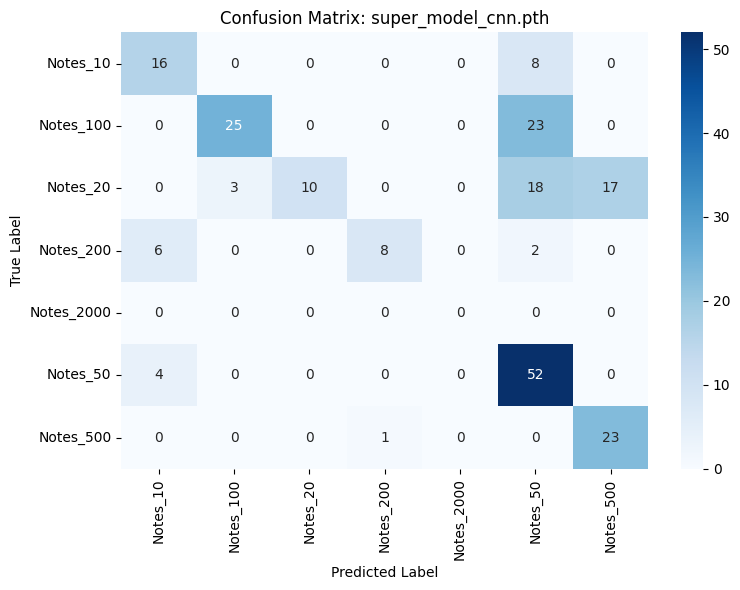


--- q2_baseline_cnn.pth ---
Accuracy: 0.4491
              precision    recall  f1-score   support

    Notes_10       0.56      0.75      0.64        24
   Notes_100       0.42      0.77      0.54        48
    Notes_20       0.89      0.17      0.28        48
   Notes_200       1.00      0.50      0.67        16
  Notes_2000       0.00      0.00      0.00         0
    Notes_50       1.00      0.05      0.10        56
   Notes_500       0.30      0.96      0.46        24

    accuracy                           0.45       216
   macro avg       0.60      0.46      0.39       216
weighted avg       0.72      0.45      0.38       216



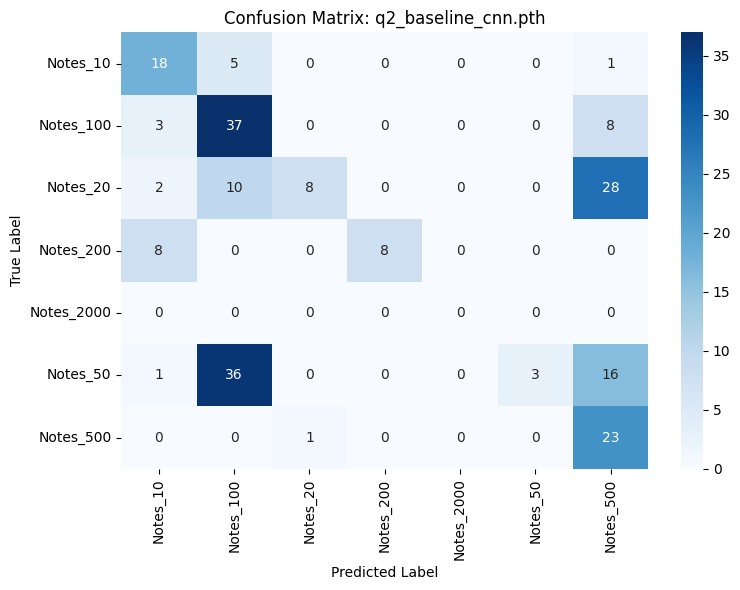


--- q2_mobile_cnn.pth ---
Accuracy: 0.5602
              precision    recall  f1-score   support

    Notes_10       0.41      0.71      0.52        24
   Notes_100       0.73      0.79      0.76        48
    Notes_20       1.00      0.19      0.32        48
   Notes_200       0.27      0.44      0.33        16
  Notes_2000       0.00      0.00      0.00         0
    Notes_50       0.56      0.61      0.58        56
   Notes_500       0.62      0.67      0.64        24

    accuracy                           0.56       216
   macro avg       0.51      0.49      0.45       216
weighted avg       0.66      0.56      0.54       216



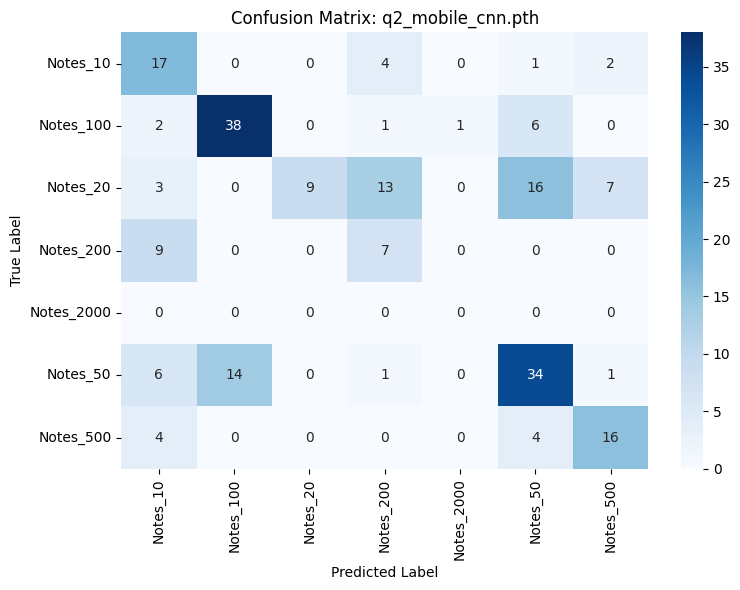


--- q2_mobile_aug_cnn.pth ---
Accuracy: 0.4676
              precision    recall  f1-score   support

    Notes_10       0.00      0.00      0.00        24
   Notes_100       0.49      0.75      0.59        48
    Notes_20       1.00      0.19      0.32        48
   Notes_200       0.83      0.31      0.45        16
  Notes_2000       0.00      0.00      0.00         0
    Notes_50       0.51      0.48      0.50        56
   Notes_500       0.32      1.00      0.49        24

    accuracy                           0.47       216
   macro avg       0.45      0.39      0.34       216
weighted avg       0.56      0.47      0.42       216



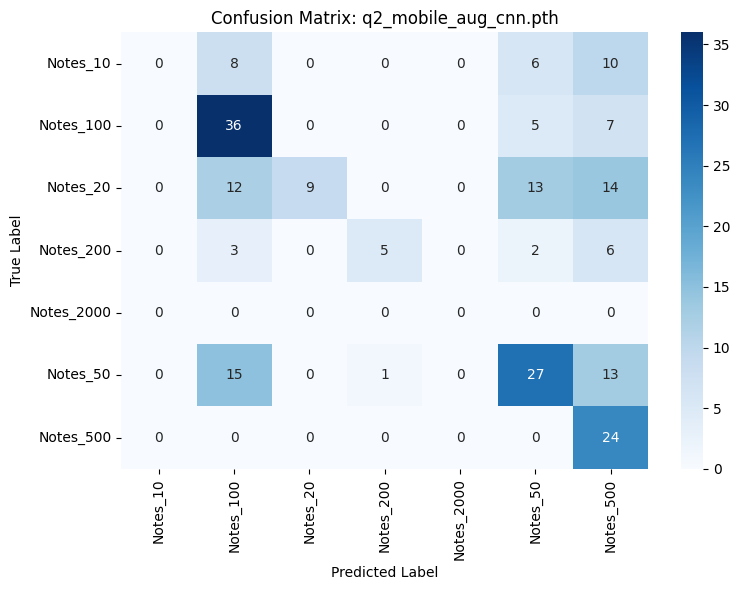

In [8]:
# ================================
# 6. INFERENCE & METRICS
# ================================
IMAGE_FOLDER = "Test_Notes_Augmented" 
MODEL_PATHS = [
    MODEL_SAVE_PATH_SUPER,
    MODEL_SAVE_PATH_BASE,
    MODEL_SAVE_PATH_MOB,
    MODEL_SAVE_PATH_MOB_AUG
]

loaded_models = []
print(f"[*] Initializing inference on {DEVICE}...")

for model_path in MODEL_PATHS:
    if not os.path.exists(model_path):
        print(f"[!] Warning: '{model_path}' not found. Skipping.")
        continue

    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    num_classes = len(ckpt["class_names"])

    if "super" in model_path.lower():
        model = SuperCurrencyCNN(num_classes)
    elif "mobile" in model_path.lower():
        model = MobileCurrencyCNN(num_classes)
    else:
        model = BaselineCurrencyCNN(num_classes)

    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()
    loaded_models.append((os.path.basename(model_path), model))

y_true_all = {name: [] for name, _ in loaded_models}
y_pred_all = {name: [] for name, _ in loaded_models}

print(f"\n[*] Scanning '{IMAGE_FOLDER}' for images...")

for img_name in os.listdir(IMAGE_FOLDER):
    if not img_name.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(IMAGE_FOLDER, img_name)
    label_number = img_name.split("_")[0]
    true_label = f"Notes_{label_number}"

    try:
        img = Image.open(img_path).convert("RGB")
    except Exception as e:
        print(f"[!] Could not open {img_name}: {e}")
        continue
    
    min_dim = min(img.size)
    img = transforms.CenterCrop(min_dim)(img)
    img_tensor = base_transform(img).unsqueeze(0).to(DEVICE)

    for model_name, model in loaded_models:
        with torch.no_grad():
            out = model(img_tensor)
            pred_idx = torch.argmax(out, dim=1).item()
        
        pred_label = class_names[pred_idx]
        y_true_all[model_name].append(true_label)
        y_pred_all[model_name].append(pred_label)

str_class_names = [str(c) for c in class_names]

for model_name, _ in loaded_models:
    y_true = y_true_all[model_name]
    y_pred = y_pred_all[model_name]

    if not y_true:
        continue

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, labels=str_class_names, zero_division=0)
    
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(report)

    cm = confusion_matrix(y_true, y_pred, labels=str_class_names)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=str_class_names, yticklabels=str_class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()  # Displays right in the notebook

### 2B.5 Confusion Matrix Analysis (Model-wise)

(a) Confusion matrices have been computed and displayed for **all models** in the inference cell above using `sklearn.metrics.confusion_matrix` and `seaborn.heatmap`:
- `super_model_cnn.pth`
- `q2_baseline_cnn.pth`
- `q2_mobile_cnn.pth`
- `q2_mobile_aug_cnn.pth`

(b) Two most common confusion pairs (true class -> predicted class), model-wise:

1. **super_model_cnn.pth**
- `Notes_100 -> Notes_50` : 23
- `Notes_20 -> Notes_50` : 18
- Likely reason: stronger reliance on global color/texture; denomination numerals are not always dominant in learned features.

2. **q2_baseline_cnn.pth**
- `Notes_50 -> Notes_100` : 36
- `Notes_20 -> Notes_500` : 28
- Likely reason: lower-capacity feature extractor mixes visually similar note layouts and misses fine denomination-specific details.

3. **q2_mobile_cnn.pth**
- `Notes_20 -> Notes_50` : 16
- `Notes_50 -> Notes_100` : 14
- Likely reason: compact/mobile architecture trades detail sensitivity for efficiency, causing confusion among notes with similar color bands and text regions.

4. **q2_mobile_aug_cnn.pth**
- `Notes_50 -> Notes_100` : 15
- `Notes_20 -> Notes_500` : 14
- Likely reason: augmentation improved robustness but did not explicitly force attention to denomination-number/security regions.

(c) One targeted strategy (beyond generic augmentation), model-wise:

- **super_model_cnn.pth**: use two inputs — full note + cropped denomination area — and combine both features.
- **q2_baseline_cnn.pth**: focus training more on commonly confused pairs (`50/100`, `20/500`) by giving these mistakes higher loss weight.
- **q2_mobile_cnn.pth**: add a small attention module in the last blocks to help the model look at important denomination regions.
- **q2_mobile_aug_cnn.pth**: add an embedding loss so same-class notes stay closer and confused classes are pushed farther apart.

Note: `Notes_2000` has zero support in this test set (I found out later it got removed from circulation again a bit late), so confusion analysis for that class is not meaningful here.

#### Grad-CAM


[*] Generating Grad-CAM Heatmaps...

Evaluating: 50_4_orig.jpeg (True: Notes_50)


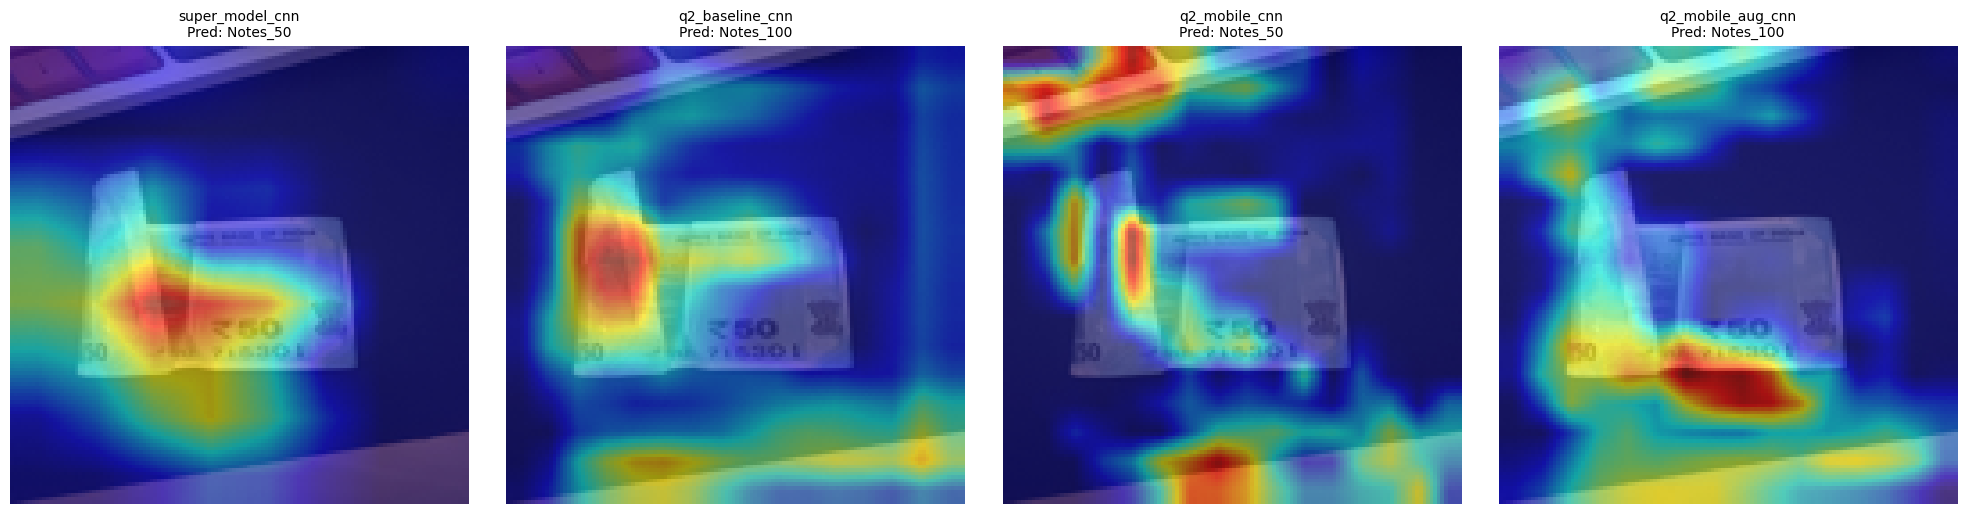


Evaluating: 500_3_rot180.jpeg (True: Notes_500)


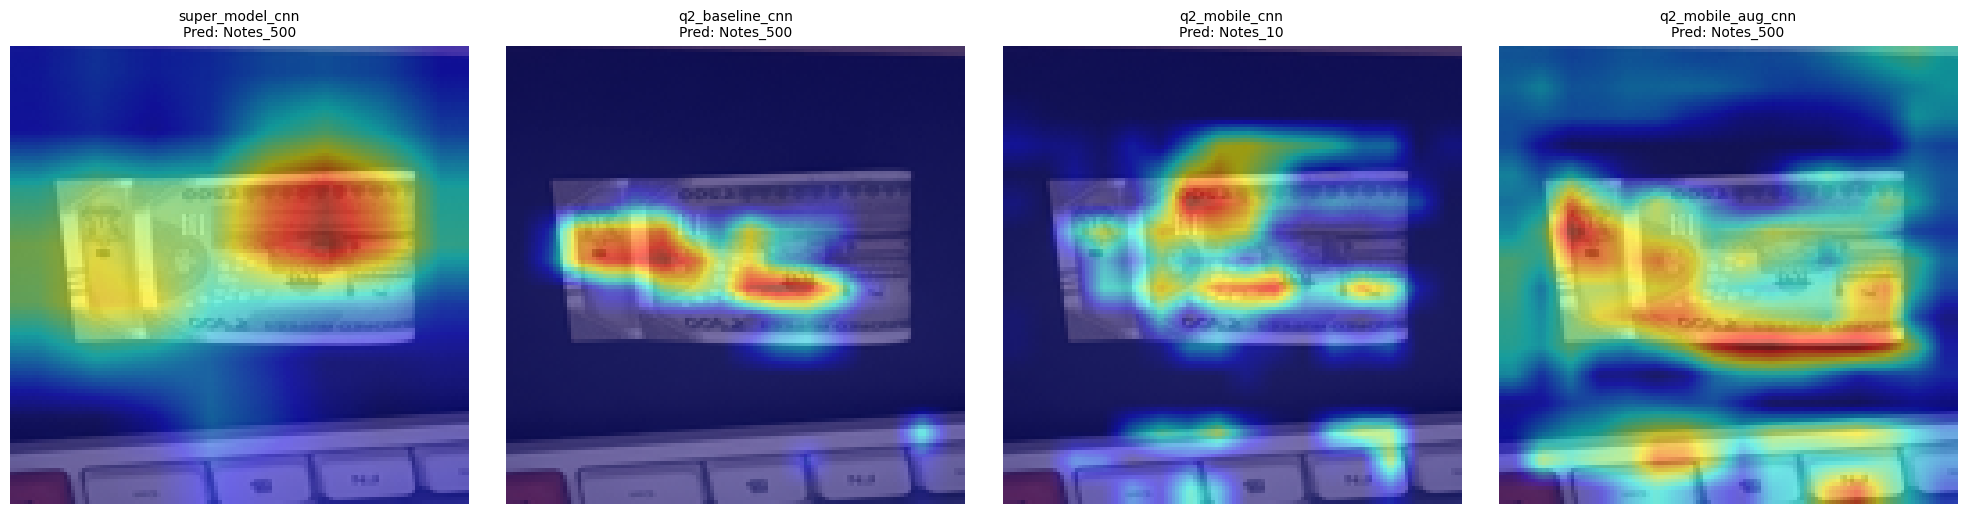


Evaluating: 100_3_orig.jpeg (True: Notes_100)


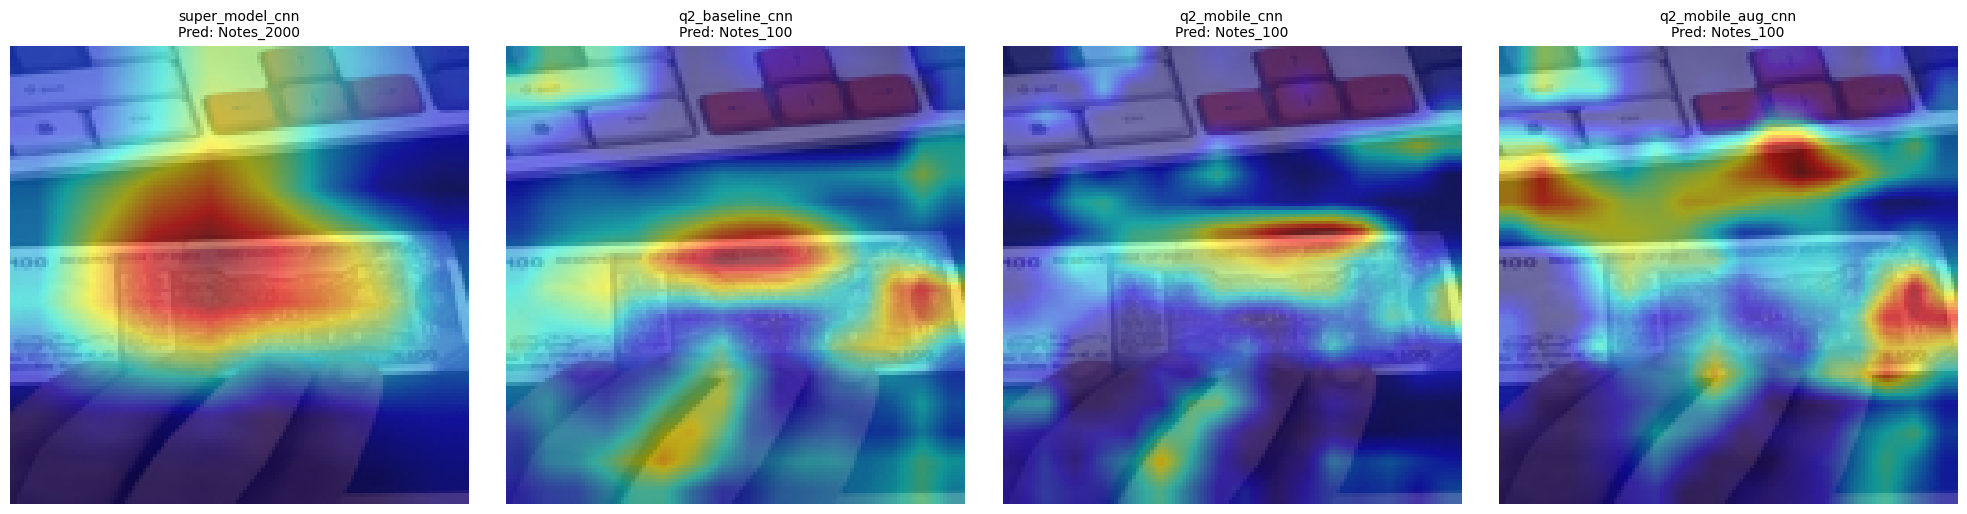

In [9]:
# ================================
# 7. GRAD-CAM VISUALIZATION
# ================================
TARGET_IMAGES = [
    "Test_Notes_Augmented/50_4_orig.jpeg", 
    "Test_Notes_Augmented/500_3_rot180.jpeg",
    "Test_Notes_Augmented/100_3_orig.jpeg"
]

def get_gradcam_target_layer(model, model_name):
    if "super" in model_name.lower():
        return [model.features[4][0]]
    elif "mobile" in model_name.lower():
        return [model.block4[0]]
    else:
        return [model.features[3][0]]

print(f"\n[*] Generating Grad-CAM Heatmaps...")

for img_path in TARGET_IMAGES:
    if not os.path.exists(img_path):
        print(f"[!] Image {img_path} not found. Skipping.")
        continue

    img_name = os.path.basename(img_path)
    true_label_str = f"Notes_{img_name.split('_')[0]}"

    print(f"\nEvaluating: {img_name} (True: {true_label_str})")

    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((128, 128))
    rgb_img = np.float32(img_resized) / 255.0
    input_tensor = base_transform(img_resized).unsqueeze(0).to(DEVICE)

    # Plot horizontally to compare models side-by-side
    fig, axes = plt.subplots(1, len(loaded_models), figsize=(5 * len(loaded_models), 5))
    if len(loaded_models) == 1:
        axes = [axes]

    for ax, (model_name, model) in zip(axes, loaded_models):
        safe_model_name = model_name.replace('.pth', '')
        
        with torch.no_grad():
            outputs = model(input_tensor)
            pred_idx = torch.argmax(outputs, dim=1).item()
            pred_label = class_names[pred_idx]
        
        target_layers = get_gradcam_target_layer(model, safe_model_name)
        cam = GradCAM(model=model, target_layers=target_layers)
        
        grayscale_cam = cam(input_tensor=input_tensor)[0, :]
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        
        ax.imshow(visualization)
        ax.axis('off')
        ax.set_title(f"{safe_model_name}\nPred: {pred_label}", fontsize=10)
        
    plt.tight_layout()
    plt.show()  # Displays right in the notebook

### B.4 Interpretability with Grad-CAM (All Models)

(a) Grad-CAM heatmaps were generated with `pytorch-grad-cam` for the final convolutional layer of each model and overlaid on the original images:
- `super_model_cnn`: `model.features[4][0]`
- `q2_baseline_cnn`: `model.features[3][0]`
- `q2_mobile_cnn`: `model.block4[0]`
- `q2_mobile_aug_cnn`: `model.block4[0]`

(b) For the three shown denominations (`Notes_50`, `Notes_500`, `Notes_100`), model-wise predictions are:

| Model             | 50_4_orig (True 50) | 500_3_rot180 (True 500) | 100_3_orig (True 100) | Correct / 3 |
|---                |---                  |---                      |---                    |---|
| super_model_cnn   | 50                  | 500                     | 2000                  | 2/3 |
| q2_baseline_cnn   | 100                 | 500                     | 100                   | 2/3 |
| q2_mobile_cnn     | 50                  | 10                      | 100                   | 2/3 |
| q2_mobile_aug_cnn | 100                 | 500                     | 100                   | 2/3 |

The overlays for these three denominations are shown above for all four models.

(c) Across models, high-performing models (`super_model_cnn` and `q2_mobile_aug_cnn`) place stronger attention on note-internal semantic regions (denomination numeral/text band and portrait-adjacent structures), and this is more consistent across the three denominations. The baseline model attends to useful note regions but is more diffuse and sometimes shifts toward colour/texture cues, which aligns with its `50 -> 100` confusion. The plain mobile model shows the least stable attention, with saliency drifting to broad texture/background regions, matching its larger misclassification pattern (`50 -> 500`, `100 -> 2000`). Overall, attention consistency to denomination-specific local cues is highest in the super and augmented mobile models, and weakest in the plain mobile model.